In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LOAD THE DATA

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


EDA

In [4]:
df.shape

(32581, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
df["loan_status"].unique()

array([1, 0])

In [8]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

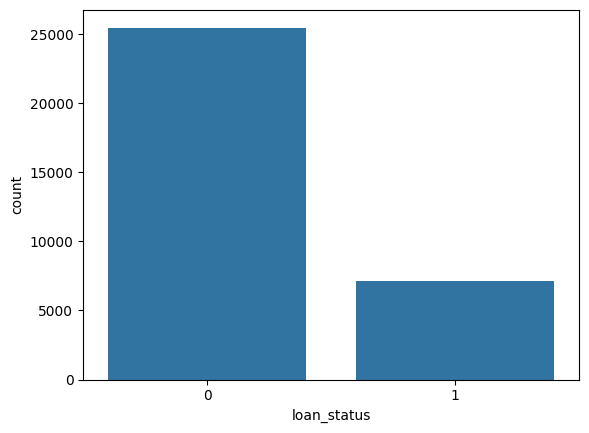

In [9]:
sns.countplot(x="loan_status" , data=df)

In [10]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [11]:
numeric_cols=df.select_dtypes(include="number")
numeric_cols.columns



Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

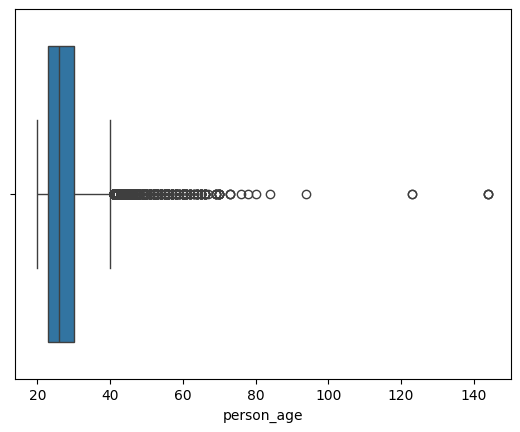

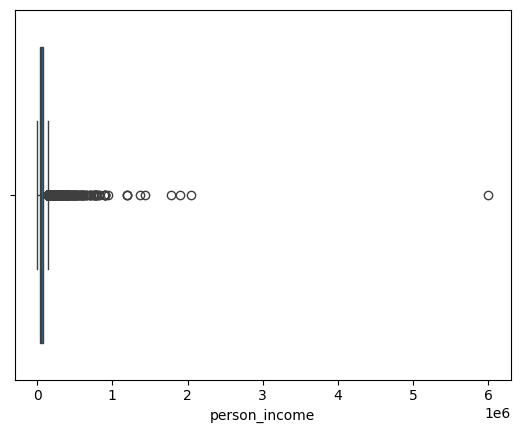

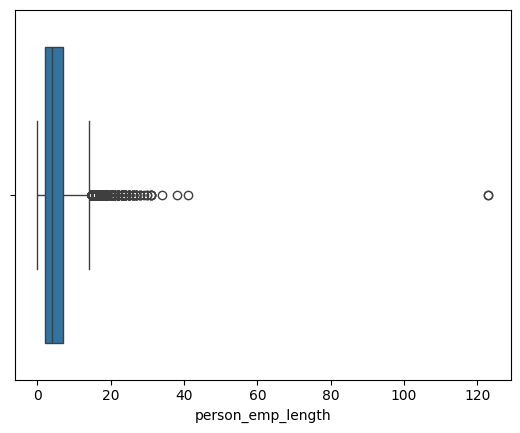

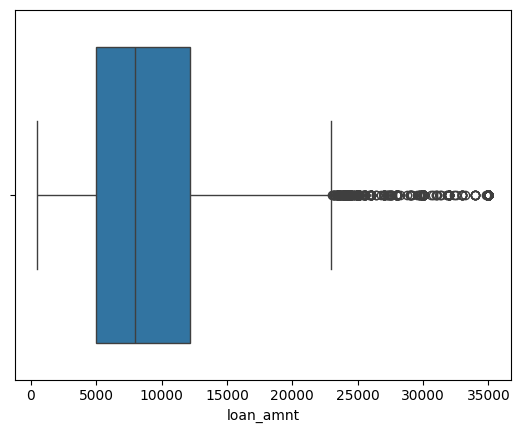

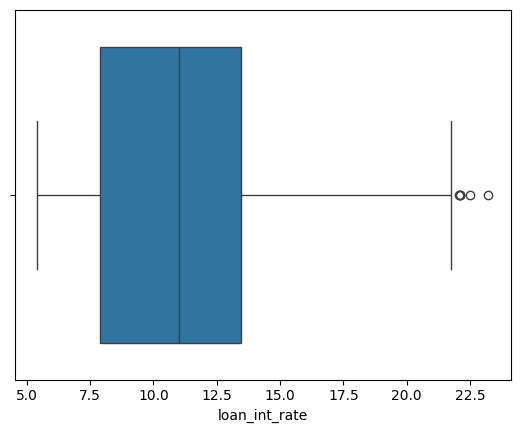

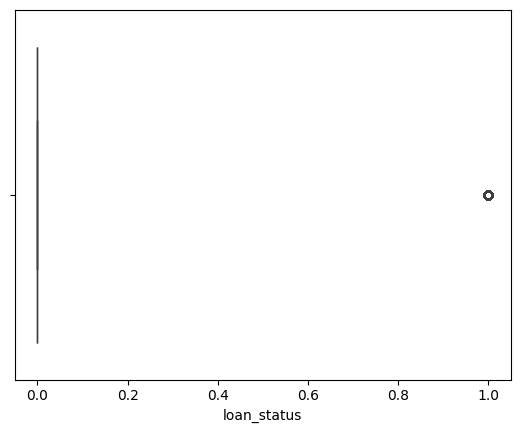

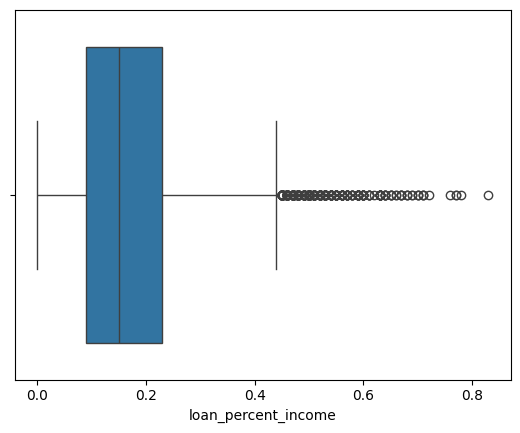

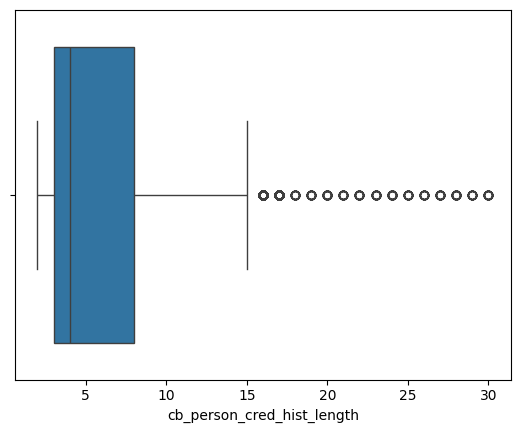

In [12]:
for i in numeric_cols:
    sns.boxplot(x=df[i])
    plt.show()

<Axes: >

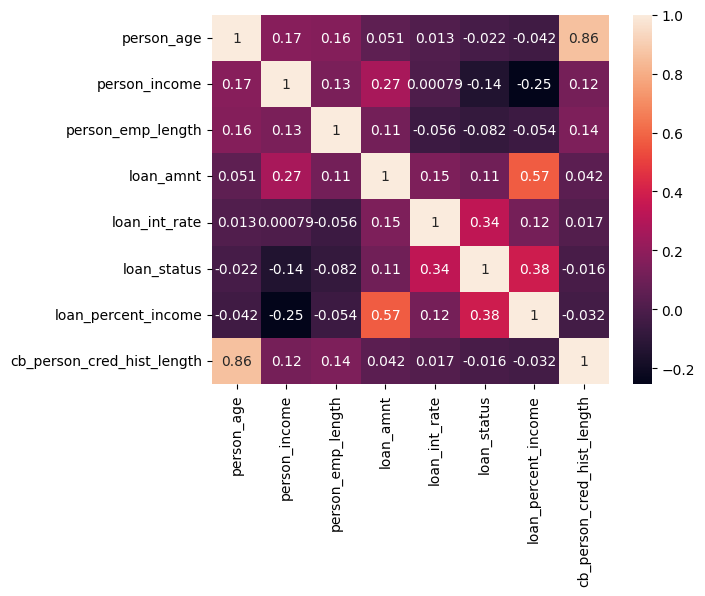

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

CLEAN DATA

In [14]:
df_copy=df.copy()

print(f"total rows{df_copy.shape[0]}")

total rows32581


In [15]:
df_copy.drop_duplicates(inplace=True)
print(f"after removing duplicates rows {df_copy.shape[0]}")

after removing duplicates rows 32416


In [16]:
#remove ages below 18 and above 100
df_copy=df_copy[df_copy['person_age'] >=18 ]
df_copy=df_copy[df_copy['person_age'] <=100]


#remove emp lenght greater than 60
df_copy =df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy =df_copy[df_copy['person_emp_length'] <= 60]

In [17]:
#remove the rows with zero and negative income and loan amt
df_copy=df_copy[df_copy['loan_amnt'] >0]

FEATURES , TARGET AND TRAIN TEST SPLIT

In [18]:
X = df_copy.drop("loan_status", axis=1)

y = df_copy['loan_status']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42 , stratify=y)

In [20]:
numeric_col = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate','loan_percent_income',
       'cb_person_cred_hist_length']

categorical_col = ['person_home_ownership' , 'loan_intent' , 'loan_grade' , 'cb_person_default_on_file']

In [21]:
#handle class imbalance
# 0 = no loan
#1 = yes loan


neg , pos =np.bincount(y_train)
scale_weights=neg/pos

DATA PREPROCESSING AND PIPELINING

In [22]:
#logistic regression - impute +Scale numeric + ,impute + one hot endcoding 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder , StandardScaler

preprocessor_lr = ColumnTransformer(
    transformers=[
        #pipeline fpr numeric values
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_col),
        #pipeline for categorical data
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_col)
    ]
)



In [23]:
#XG- Boost impute numeric only (no scaling) , impute + one hot encoding

preprocessor_xg = ColumnTransformer(
    transformers=[
        
        #pipeline fpr numeric values
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ]), numeric_col),

        #pipeline for categorical data
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_col)
    ]
)

HELPING FUCTION FOR  EVALUATION

In [24]:
from sklearn.metrics import accuracy_score, precision_recall_curve,precision_score,recall_score,f1_score,confusion_matrix,classification_report

def evaluate_model(model_name , model , X_test,y_test ,threshold=None):
    
    y_pred_prob=model.predict_proba(X_test)[:,1]
    if threshold:
        y_pred = (y_pred_prob > threshold).astype(int)
    else:
        y_pred=model.predict(X_test)


    accuracy = accuracy_score(y_test, y_pred)#overall model perfromance
    precision = precision_score(y_test, y_pred)#of the one i have picked how many are actually right
    recall = recall_score(y_test, y_pred)#out of everything thats was really there how much did you manage to fong
    f1 = f1_score(y_test, y_pred)#harmonic meaan of precison and recall



   # confusion matrix
    cm = confusion_matrix(y_test,y_pred)
    class_report=classification_report(y_test,y_pred)

    
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print()
    print(f"{model_name} : classification report")
    print(class_report)


    #plotting confusion matrix
    sns.heatmap(cm,annot=True,fmt='d')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    #plotting ROC-AUC curve 
    precisions , recalls ,threshold = precision_recall_curve(y_test,y_pred_prob)
    plt.plot(recalls,precisions)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} Recall-Precison curve")
    plt.show()





Cross Validation

In [25]:
from sklearn.model_selection import StratifiedKFold , cross_validate

cv = StratifiedKFold(n_splits=5 , shuffle=True , random_state=42)

scoring ={'roc_auc':'roc_auc' ,'accuracy':'accuracy' ,'precision':'precision' , 'recall':'recall' , 'f1':'f1'}


In [26]:
from sklearn.linear_model import LogisticRegression

lr_cv_pipeline = Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier' , LogisticRegression(max_iter=100 , class_weight="balanced" , random_state=42))
])

In [27]:
lr_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [28]:
# XGBoost Model
from xgboost import XGBClassifier

xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=scale_weights,
        random_state=42,
        n_jobs=-1
    ))
])

In [29]:
xgb_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [30]:
for cv_name, pipe in [
    ('Logistic Regression', lr_cv_pipeline),
    ('XGBoost', xgb_cv_pipeline)
]:
    
    cv_result = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )


    print(cv_name)
    print(f"ROC-AUC:{cv_result['test_roc_auc'].mean()}")
    print(f"Accuracy:{cv_result['test_accuracy'].mean()}")
    print(f"Recall:{cv_result['test_recall'].mean()}")
    print(f"Precision{cv_result['test_precision'].mean()}")
    print(f"F1:{cv_result['test_f1'].mean()}")
    print()

Logistic Regression
ROC-AUC:0.8713404164641778
Accuracy:0.8110233618747266
Recall:0.7792147057128033
Precision0.5436005160273509
F1:0.6404194397951647

XGBoost
ROC-AUC:0.9470834775851917
Accuracy:0.9187462103272843
Recall:0.7960963471109318
Precision0.822334499197852
F1:0.8088818803731103



In [31]:
#BASELINE MODEL WITH HYPER PARAMETER
baseline_model = Pipeline([
    ('processor' , preprocessor_lr),
    ('classifier' ,LogisticRegression(class_weight='balanced'))

])

baseline_model.fit(X_train,y_train)

c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Pipeline(steps=[('processor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

In [32]:
#XGBOOST with hyper parameter

xg_model = Pipeline([
    ('preprocessor',preprocessor_xg),
    ('classifier',XGBClassifier( learning_rate=0.1,
        scale_pos_weight=scale_weights,
        random_state=42))
])

xg_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

Accuracy : 0.8163029895222532
Precision: 0.5529560543787544
Recall   : 0.7787177203918076
F1 Score : 0.646699944536883

Baseline Logistic model : classification report
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      8157
           1       0.55      0.78      0.65      2246

    accuracy                           0.82     10403
   macro avg       0.74      0.80      0.76     10403
weighted avg       0.85      0.82      0.83     10403



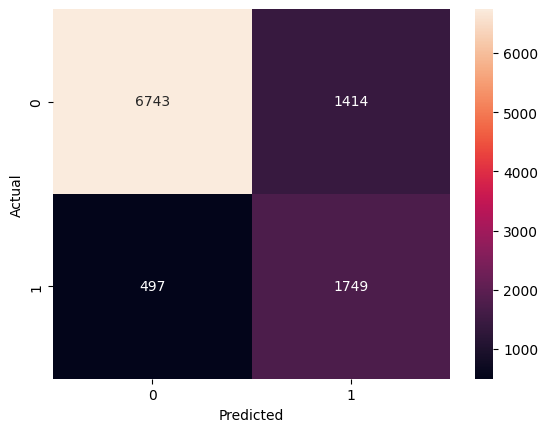

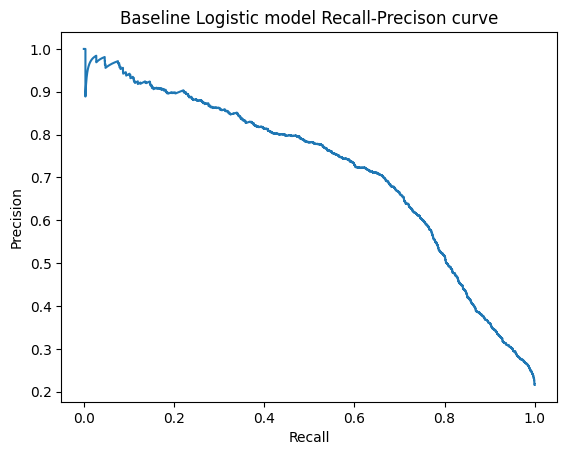

In [33]:
evaluate_model("Baseline Logistic model" ,baseline_model ,X_test,y_test )

Accuracy : 0.9181005479188695
Precision: 0.8257009345794393
Recall   : 0.7867319679430098
F1 Score : 0.8057455540355677

XGboost With Hyperparameter tuning : classification report
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      8157
           1       0.83      0.79      0.81      2246

    accuracy                           0.92     10403
   macro avg       0.88      0.87      0.88     10403
weighted avg       0.92      0.92      0.92     10403



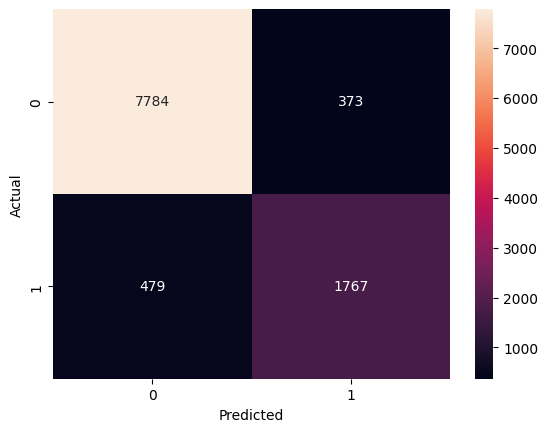

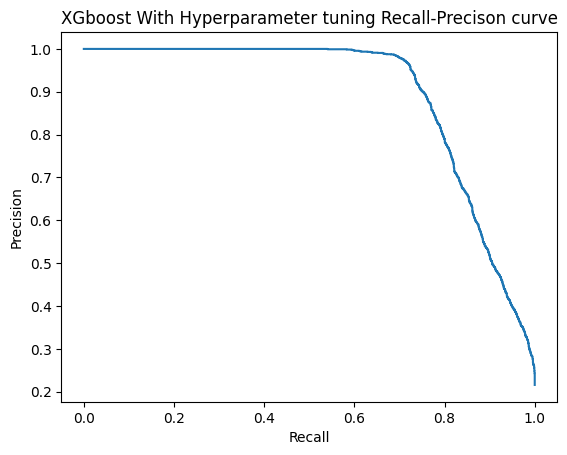

In [34]:
evaluate_model("XGboost With Hyperparameter tuning" ,xg_model , X_test , y_test )

In [35]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint , uniform

param_grid = {
    'classifier__n_estimators': randint(150,600),
    'classifier__max_depth': randint(3, 9),
    'classifier__learning_rate':uniform(0.01, 0.5),
    'classifier__subsample': uniform(0.6,0.4),
    'classifier__colsample_bytree': uniform(0.6,0.4),
    'classifier__min_child_weight':randint(1, 10),
    'classifier__gamma': uniform(0,5)
}

In [36]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000236C2567610>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000236C21CD550>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000236C2567250>},
                   random_state=42, scoring='average_precision', verbose=1)

In [37]:
print(f"score after tuning :{random_search.best_score_}")

score after tuning :0.9032374280604027


OPTIMIZNG THE CLASSIFICATION THRESHOLD
 

c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn

Accuracy : 0.7841007401711045
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

XGBoost : classification report
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      8157
           1       0.00      0.00      0.00      2246

    accuracy                           0.78     10403
   macro avg       0.39      0.50      0.44     10403
weighted avg       0.61      0.78      0.69     10403



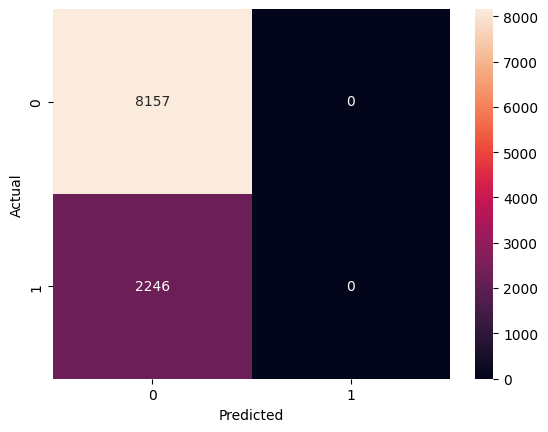

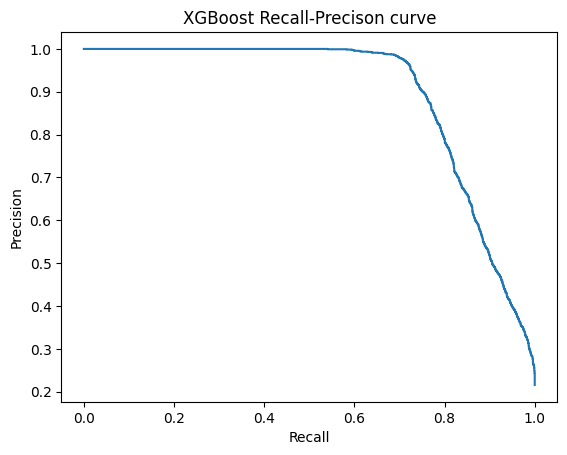

In [38]:
# Get the probability of class 1 from XGBoost
prob = xg_model.predict_proba(X_test)[:, 1]

# For each threshold calculate Precision and Recall
precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    prob
)

# Calculate F1 score for each threshold
f1 = 2 * (precisions - recalls) / (precisions + recalls + 1e-9)

# Get the threshold that produces the highest F1 score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

# Evaluate the XGBoost model using that threshold
evaluate_model(
    "XGBoost",
    xg_model,
    X_test,
    y_test,
    best_threshold
)


PROBABILITY CALIBRATION

In [39]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

best_model=random_search.best_estimator_
# Calibrate XGBoost model
calibrated_xgb = CalibratedClassifierCV(
    estimator=best_model,
    method='sigmoid',
    cv=5
)

calibrated_xgb.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.0627471299151353),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=6,
                                                                max_leaves=None,
                                                                min_child_weight=4,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=435,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [40]:
# Original XGBoost probabilities
uncalibrated = xg_model.predict_proba(X_test)[:, 1]

# Calibrated XGBoost probabilities
calibrated = calibrated_xgb.predict_proba(X_test)[:, 1]

In [41]:
# Calibration curve data
actual_uncal, predicted_uncal = calibration_curve(
    y_test,
    uncalibrated,
    n_bins=10,
)

actual_cal, predicted_cal = calibration_curve(
    y_test,
    calibrated,
    n_bins=10,
)

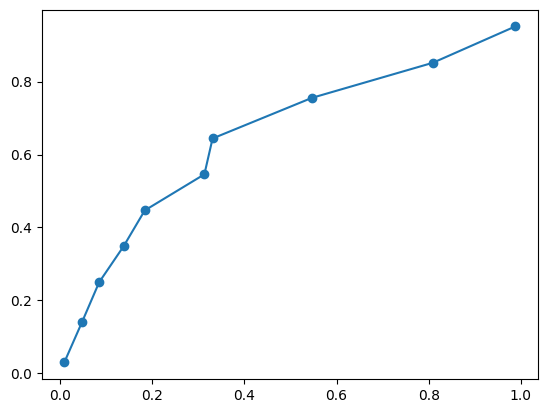

In [42]:
# Plot calibration curve

plt.plot(
    actual_uncal,
    predicted_cal,
    marker='o',
    label='Uncalibrated XGBoost'
)


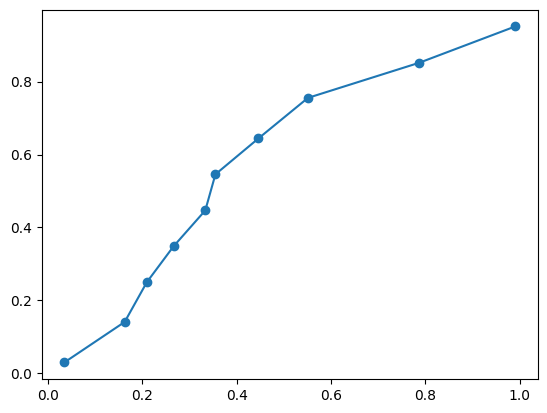

In [43]:
plt.plot(
    actual_cal,
    predicted_cal,
    marker='o',
    label='Calibrated XGBoost'
)

SHAP

In [44]:
# Get XGBoost classifier
xgb_classifier = xg_model.named_steps['classifier']

# Transform test data
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

# Get feature names
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [45]:
X_test_df = pd.DataFrame(X_test_transformed , columns=feature_names)

In [46]:
import shap
explainer = shap.TreeExplainer(xgb_classifier)

c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
shap_values = explainer.shap_values(X_test_df)

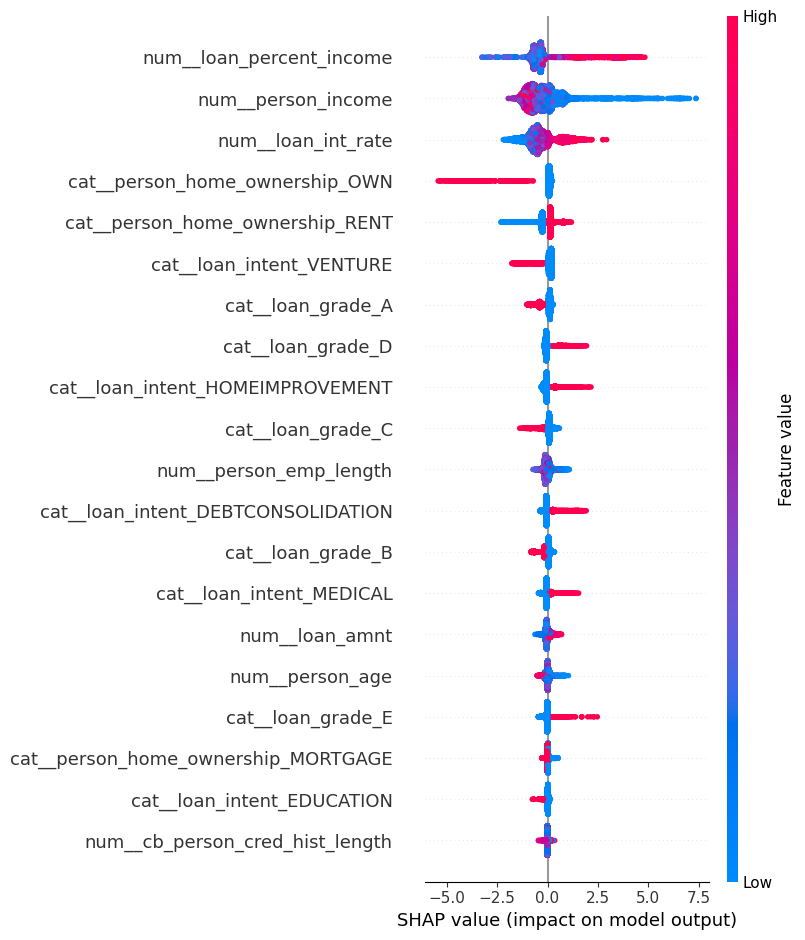

In [48]:
#gloabal explaination
shap.summary_plot(shap_values ,X_test_df)

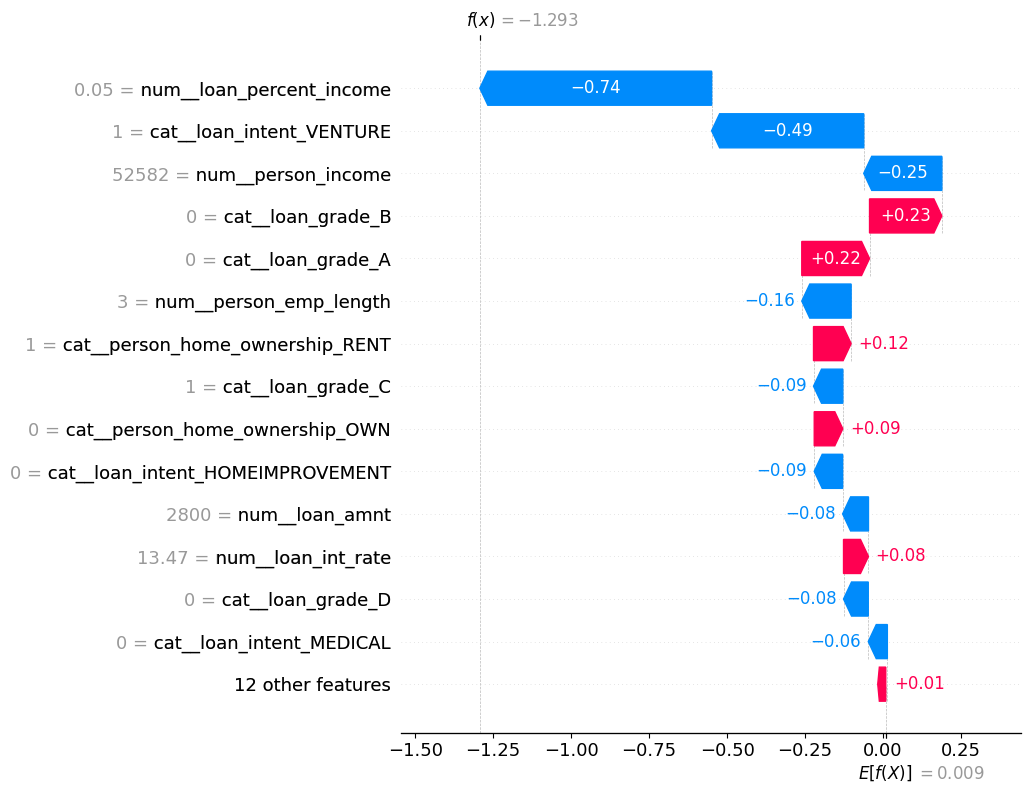

In [49]:
#local explaination


# Select the 5th applicant
row_index = 5

# Create SHAP Explanation for that applicant
shap_exp = shap.Explanation(
    values=shap_values[row_index],
    base_values=explainer.expected_value,
    data=X_test_transformed[row_index],
    feature_names=feature_names
)

shap.plots.waterfall(shap_exp, max_display=15)

In [50]:
#false positive and false negative


y_pred = random_search.predict(X_test)

result_df =X_test.copy()
result_df['actual']=y_test
result_df['predicted']=y_pred

In [51]:
# Identify False Positives
false_positive = result_df[
    (result_df['actual'] == 0) &
    (result_df['predicted'] == 1)
]

# Identify False Negatives
false_negative = result_df[
    (result_df['actual'] == 1) &
    (result_df['predicted'] == 0)
]

print("False Positive:", len(false_positive))
print("False Negative:", len(false_negative))

# Display records


False Positive: 350
False Negative: 461


In [52]:
import joblib

In [53]:
joblib.dump(calibrated_xgb,"credit_risk_model.pkl")

['credit_risk_model.pkl']

In [54]:
joblib.dump(best_threshold,"best_threshold.pkl")

['best_threshold.pkl']

In [56]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. Get probabilities from the CALIBRATED model
calibrated_proba = calibrated_xgb.predict_proba(X_test)[:, 1]

# 2. Find the threshold that maximizes F1
precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    calibrated_proba
)

f1_scores = 2 * (precisions * recalls) / (
    precisions + recalls + 1e-9
)

best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print("New threshold:", best_threshold)


New threshold: 0.6451746748415385


In [57]:
joblib.dump(best_threshold,"best_threshold.pkl")

['best_threshold.pkl']